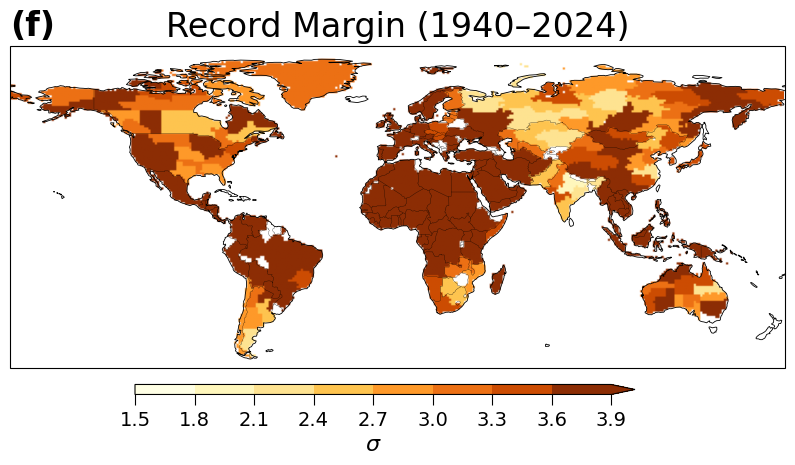

In [1]:
# ==========================================
# Figure: Record Margin (1981–2024)
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# ==========================================
# 1. Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]

lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max()
]

# ==========================================
# 2. Low fidelity mask
# ==========================================
fidelity_mask = (
    fidelity_ds["fidelity_score"] == 3
).values

land_mask = ~np.isnan(region_id_map)

fill_grey_mask = (
    land_mask & (~fidelity_mask)
)

SCATTER_STEP = 3

lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(
    fill_grey_mask,
    dtype=bool
)

sparse_mask[
    ::SCATTER_STEP,
    ::SCATTER_STEP
] = True

low_fidelity_sparse = (
    fill_grey_mask & sparse_mask
)

# ==========================================
# 3. Record margin calculation
# ==========================================

t2m = ds["t2m_hottest"]

# baseline
t2m_base = t2m.sel(
    year=slice(1940, 1980)
)
baseline_max = t2m_base.mean(
    dim="year"
)

baseline_std = t2m_base.std(
    dim="year"
)

# full-period record
record_2024 = t2m.max(
    dim="year"
)

# standardized record margin
record_margin = (
    record_2024 - baseline_max
) / baseline_std

# avoid division by zero
record_margin = record_margin.where(
    baseline_std > 0
)

# ==========================================
# 4. Map regional values to grid
# ==========================================

summary_map = np.full(
    region_id_map.shape,
    np.nan
)

for rid in record_margin.region_id.values:

    mask = (
        region_id_map.values == rid
    )

    summary_map[mask] = (
        record_margin.sel(
            region_id=rid
        ).values
    )
# ==========================================
# 5. Colormap and bounds
# ==========================================
bounds = [1.5, 1.8, 2.1, 2.4, 2.7, 3.0, 3.3, 3.6, 3.9]
# 0–1.5σ
colors_low = [
    "#ffffe5",
    "#fff7bc",
    "#fee391",
    "#fec44f"
]

# >1.5σ
colors_high = [
    "#fe9929",
    "#ec7014",
    "#cc4c02",
    "#8c2d04"
]

colors = (
    colors_low + colors_high
)

cmap = ListedColormap(colors)

cmap.set_bad("white")

norm = BoundaryNorm(
    bounds,
    cmap.N
)

# ==========================================
# 6. Remove zeros for plotting
# ==========================================
summary_map_plot = summary_map.copy()

summary_map_plot[
    summary_map_plot == 0
] = np.nan

# ==========================================
# 7. Plot figure
# ==========================================
fig = plt.figure(
    figsize=(10,5)
)

ax = fig.add_subplot(
    111,
    projection=ccrs.PlateCarree()
)

ax.set_extent([
    -180,
    180,
    -60,
    90
])

ax.coastlines(
    linewidth=0.6
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.2
)

ax.set_title(
    "Record Margin (1940–2024)",
    fontsize=24
)

im = ax.imshow(
    summary_map_plot,
    origin="lower",
    extent=extent,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

# ==========================================
# 8. Grey dots for low fidelity regions
# ==========================================
# ax.scatter(
#     lon2d[low_fidelity_sparse],
#     lat2d[low_fidelity_sparse],
#     s=3,
#     color="grey",
#     marker="o",
#     edgecolors="none",
#     transform=ccrs.PlateCarree(),
#     zorder=5
# )

# ==========================================
# 9. Panel label
# ==========================================
ax.text(
    0.00,
    1.03,
    "(f)",
    transform=ax.transAxes,
    fontsize=24,
    ha="left",
    fontweight="bold"
)

# ==========================================
# 10. Colorbar
# ==========================================
cax = fig.add_axes([
    0.25,
    0.12,
    0.5,
    0.02
])

cb = fig.colorbar(
    plt.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    ),
    cax=cax,
    orientation="horizontal",
    extend="max"
)

cb.set_label(
    r"$\sigma$",
    fontsize=16
)

cb.set_ticks(bounds)

cb.set_ticklabels([1.5, 1.8, 2.1, 2.4, 2.7, 3.0, 3.3, 3.6, 3.9])

cb.ax.tick_params(
    labelsize=14,
    length=8
)

# ==========================================
# 11. Save figure
# ==========================================
plt.savefig(
    "Fig_record_margin.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

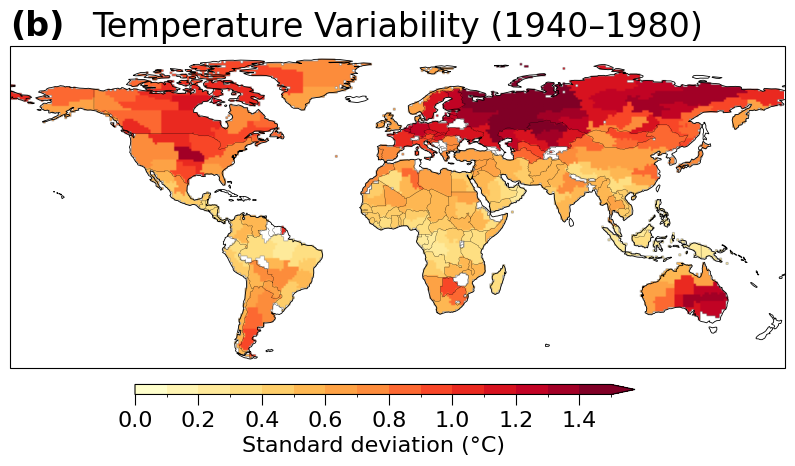

In [2]:
# ==========================================
# Figure: Spatial distribution of std_t2m
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# ==========================================
# 1. Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 1980))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# 2. Low fidelity mask
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values
land_mask = ~np.isnan(region_id_map)
fill_grey_mask = land_mask & (~fidelity_mask)

SCATTER_STEP = 3
lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# 3. Calculate std_t2m
# ==========================================
std_t2m = ds["t2m_hottest"].std(dim="year")

std_map = np.full(region_id_map.shape, np.nan)

for rid in std_t2m["region_id"].values:
    val = std_t2m.sel(region_id=rid).item()
    std_map[region_id_map.values == rid] = val

# ==========================================
# 4. Colormap
# ==========================================
bounds = np.arange(0, 1.51, 0.1)

colors = plt.cm.YlOrRd(np.linspace(0, 1, len(bounds)-1))

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# ==========================================
# 5. Plot
# ==========================================
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax.set_extent([-180,180,-60,90])

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

ax.set_title("Temperature Variability (1940–1980)", fontsize=24)

im = ax.imshow(
    std_map,
    origin="lower",
    extent=extent,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

# fidelity scatter
# ax.scatter(
#     lon2d[low_fidelity_sparse],
#     lat2d[low_fidelity_sparse],
#     s=3,
#     color="grey",
#     marker="o",
#     edgecolors="none",
#     transform=ccrs.PlateCarree(),
#     zorder=5
# )

ax.text(
    0.0,
    1.03,
    "(b)",
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
    ha="left"
)

# ==========================================
# 6. Colorbar
# ==========================================
cax = fig.add_axes([0.25,0.12,0.5,0.02])

# === 只显示0.1刻度 ===
ticks = np.arange(0, 1.41, 0.2)

cb = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
    extend="max"
)

cb.set_label("Standard deviation (°C)", fontsize=16)

#cb.set_ticks(bounds)

cb.ax.tick_params(labelsize=16, length=8)

# ==========================================
# 7. Save
# ==========================================
plt.savefig(
    "Fig_std_t2m_spatial.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

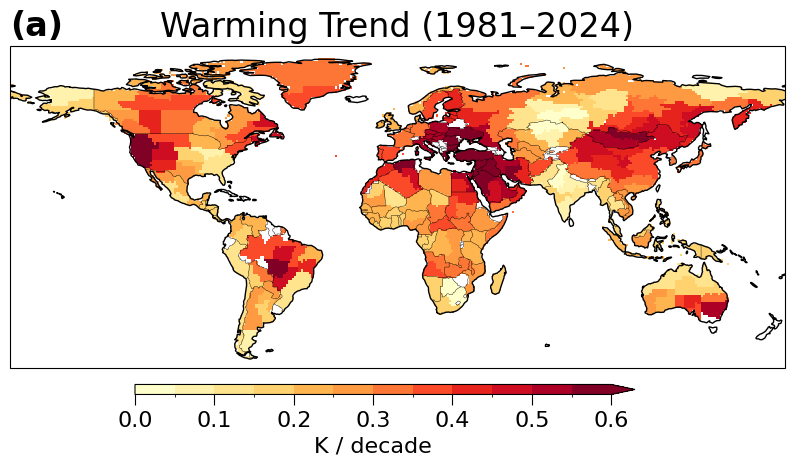

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import matplotlib.colors as mcolors

# =========================================================
# 1. Load datasets
# =========================================================
ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# =========================================================
# 2. Select period
# =========================================================
ds_sel = ds.sel(year=slice(1981, 2024))
years = ds_sel.year.values
n_regions = ds_sel.region_id.size

# =========================================================
# 3. Compute trends per region
# =========================================================
trend = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue

    slope, _, _, _, _ = linregress(years, y)
    trend[i] = slope * 10.0  # K/decade

# =========================================================
# 4. Map regional trends to lat-lon grid
# =========================================================
region_ids = region_mask_ds['region_id'].values
lat = region_mask_ds['latitude'].values
lon = region_mask_ds['longitude'].values

trend_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue

    rid = int(rid)
    if rid < n_regions:
        trend_map[region_ids == rid] = trend[rid]

# =========================================================
# 5. Apply fidelity mask
# =========================================================
fidelity_mask = (fidelity_ds['fidelity_score'] == 3).values

GREY_VAL = -9999

masked_trend = trend_map.copy()

# === 修改：levels 0–0.6，每0.05 ===
levels = np.arange(0, 0.601, 0.05)
MIN_LEVEL = levels[0]

masked_trend[(masked_trend > GREY_VAL) & (masked_trend < MIN_LEVEL)] = MIN_LEVEL

# === scatter mask ===
SCATTER_STEP = 3
lon2d, lat2d = np.meshgrid(lon, lat)

low_fidelity_mask = (~fidelity_mask) & (~np.isnan(region_ids))
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask & sparse_mask

# =========================================================
# 6. Colormap
# =========================================================
colors = plt.get_cmap("YlOrRd")(np.linspace(0, 1, len(levels) - 1))
cmap = mcolors.ListedColormap(['silver'] + list(colors))

bounds = [GREY_VAL - 0.5] + list(levels)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 7. Plot
# =========================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    lon,
    lat,
    masked_trend,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# ax.scatter(
#     lon2d[low_fidelity_sparse],
#     lat2d[low_fidelity_sparse],
#     s=3,
#     color="grey",
#     marker="o",
#     edgecolors="none",
#     transform=ccrs.PlateCarree(),
#     zorder=5
# )

ax.set_title("Warming Trend (1981–2024)", fontsize=24)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

ax.text(
    0.0,
    1.03,
    '(a)',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
    ha="left"
)

# =========================================================
# 8. Colorbar
# =========================================================
cmap_cbar = mcolors.ListedColormap(colors)
norm_cbar = mcolors.BoundaryNorm(levels, cmap_cbar.N)

sm = plt.cm.ScalarMappable(cmap=cmap_cbar, norm=norm_cbar)
sm.set_array([])

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.02])

# === 只显示0.1刻度 ===
ticks = np.arange(0, 0.61, 0.1)

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=ticks,
    extend="max"
)

cbar.ax.tick_params(labelsize=16, length=8)
cbar.set_label("K / decade", fontsize=16)

# =========================================================
# 9. Save
# =========================================================
plt.savefig(
    "ERA5_t2m_trend_hottest_month_1981_2024_masked.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

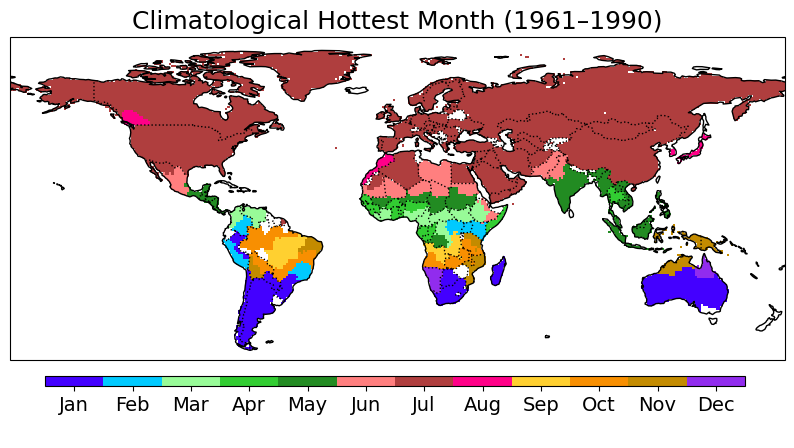

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

# === Step 1: 加载区域温度数据 ===
ds = xr.open_dataset('ERA5_region_t2m_1940_2024_currentyear03_to_nextyear02.nc')

# === Step 2: 调整 month 顺序 ===
# 获取现有 month
original_months = ds['month'].values  # 例如 [3, 4, ..., 12, 1, 2]

# 生成目标标准顺序 1-12
target_months = np.arange(1, 13)

# 计算新排序索引
sorted_indices = [np.where(original_months == m)[0][0] for m in target_months]

# 重新排序数据
ds_sorted = ds.isel(month=sorted_indices).assign_coords(month=target_months)

# === Step 3: 计算1961-1990气候态 ===
climatology = ds_sorted["t2m"].sel(year=slice(1961, 1990)).mean(dim="year")

# 每个区域最热的月份（1~12）
hottest_month = climatology.argmax(dim="month") + 1  # 从1开始计数

# === Step 4: 加载 region mask 并映射 hottest_month 到地理网格 ===
region_mask_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")
region_mask = region_mask_ds["region_id"]  # (lat, lon)

# 创建映射数组，初始化为 NaN
hottest_month_map = np.full(region_mask.shape, np.nan)

# 将 hottest_month 映射到地图网格上
region_ids = hottest_month.region_id.values
for i, rid in enumerate(region_ids):
    hottest_val = hottest_month.sel(region_id=rid).item()
    hottest_month_map[region_mask.values == rid] = hottest_val

# === Step 5: 可视化 ===

# 自定义月份颜色
month_colors = [
    "#4300FF", "#00CAFF", "#98FB98",  # 1月, 2月, 3月
    "#32CD32", "#228B22", "#FF7F7F",  # 4月, 5月, 6月
    "#AF3E3E", "#FF0088", "#FFD030",  # 7月, 8月, 9月
    "#F88F01", "#C38B00", "#912CEE"   # 10月, 11月, 12月
]
cmap = ListedColormap(month_colors)

# 创建地图图像
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mesh = ax.pcolormesh(
    region_mask.longitude, region_mask.latitude,
    hottest_month_map,
    cmap=cmap,
    vmin=1, vmax=13,
    transform=ccrs.PlateCarree()
)

# 地图细节
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.set_title("Climatological Hottest Month (1961–1990)", fontsize=18)
# ax.text(
#     0.02,
#     1.03,
#     '(a)',
#     transform=ax.transAxes,
#     fontsize=16,
#     ha="left"
# )
# 设置 colorbar
cbar_ax = fig.add_axes([0.16, 0.12, 0.7, 0.02])

cbar = fig.colorbar(
    mesh,
    cax=cbar_ax,
    orientation="horizontal"
)
cbar.set_ticks(np.arange(1.5, 13.5))
cbar.set_ticklabels([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
cbar.ax.tick_params(labelsize=14)
#cbar.set_label("Hottest Month", fontsize=12)
cbar.set_label(" ", fontsize=12)
plt.savefig('Fig_warmest_month_on_19611990.png', dpi=300, bbox_inches='tight')
plt.show()


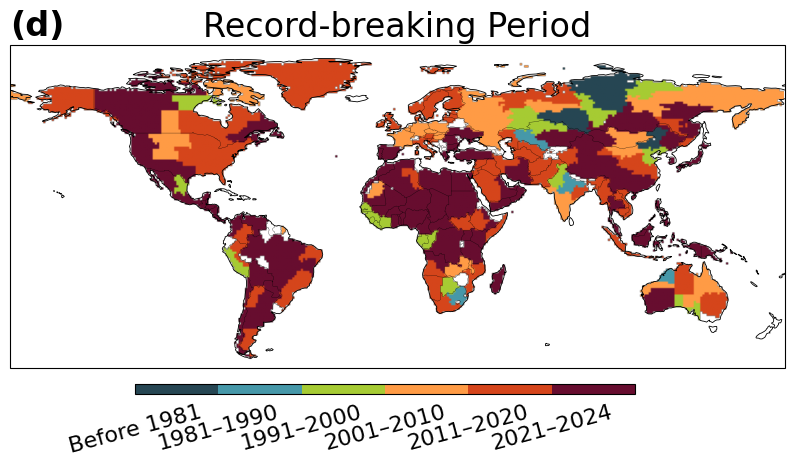

In [4]:
# ==========================================
# Figure: Record-breaking period (panel f)
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
"/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

fidelity_ds = xr.open_dataset(
"grid_comparison_fidelity_trend_corrected.nc")

region_id_map = region_mask_ds["region_id"]

lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# Low fidelity mask
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values

land_mask = ~np.isnan(region_id_map)

fill_grey_mask = land_mask & (~fidelity_mask)

SCATTER_STEP = 3

lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask)

sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True

low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# Record-breaking period calculation
# ==========================================
time_groups = {
"Before 1981":(1940,1980),
"1981–1990":(1981,1990),
"1991–2000":(1991,2000),
"2001–2010":(2001,2010),
"2011–2020":(2011,2020),
"2021–2024":(2021,2024)
}

group_labels = list(time_groups.keys())

years = ds["year"].values

max_year_idx = ds["t2m_hottest"].argmax(dim="year")

max_years = xr.DataArray(years[max_year_idx.values],dims=["region_id"])

group_array = np.full(max_years.shape,"",dtype=object)

for label,(start,end) in time_groups.items():

    mask = (max_years.values>=start)&(max_years.values<=end)

    group_array[mask]=label

group_int = np.full(group_array.shape,np.nan)

for i,label in enumerate(group_labels):

    group_int[group_array==label]=i

group_map = np.full(region_id_map.shape,np.nan)

for rid in range(len(group_int)):

    group_map[region_id_map.values==rid] = group_int[rid]

# ==========================================
# Colormap
# ==========================================
time_colors = {
"Before 1981":"#264653",   # 
"1981–1990":"#4698A9",     # 
"1991–2000":"#A6CB33",     # 
"2001–2010":"#FF9B45",     # 橙
"2011–2020":"#D5451B",     # 红橙
"2021–2024":"#670D2F"      # 深酒红
}

colors = [time_colors[l] for l in group_labels]

cmap = ListedColormap(colors)

bounds = [i-0 for i in range(len(group_labels)+1)]

norm = BoundaryNorm(bounds,cmap.N)

# ==========================================
# Plot
# ==========================================
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111,projection=ccrs.PlateCarree())

ax.set_extent([-180,180,-60,90])

ax.coastlines(linewidth=0.6)

ax.add_feature(cfeature.BORDERS,linewidth=0.2)

ax.set_title("Record-breaking Period",fontsize=24)

im = ax.imshow(
group_map,
origin="lower",
extent=extent,
transform=ccrs.PlateCarree(),
cmap=cmap,
norm=norm
)

# fidelity scatter
# ax.scatter(
# lon2d[low_fidelity_sparse],
# lat2d[low_fidelity_sparse],
# s=3,
# color="grey",
# marker="o",
# edgecolors="none",
# transform=ccrs.PlateCarree(),
# zorder=5
# )

ax.text(
0.0,1.03,"(d)",
transform=ax.transAxes,
fontsize=24,
fontweight='bold',
)

# ==========================================
# Colorbar
# ==========================================
cax = fig.add_axes([0.25,0.12,0.5,0.02])

cb = fig.colorbar(
plt.cm.ScalarMappable(cmap=cmap,norm=norm),
cax=cax,
orientation="horizontal"
)

cb.set_ticks(np.arange(len(group_labels)))

cb.set_ticklabels(group_labels)

cb.ax.tick_params(labelsize=16,length=2,rotation=15)

cb.ax.xaxis.set_ticks_position('none')


# ==========================================
# Save
# ==========================================
plt.savefig(
"Fig_record_period.pdf",
dpi=300,
bbox_inches="tight"
)

plt.show()

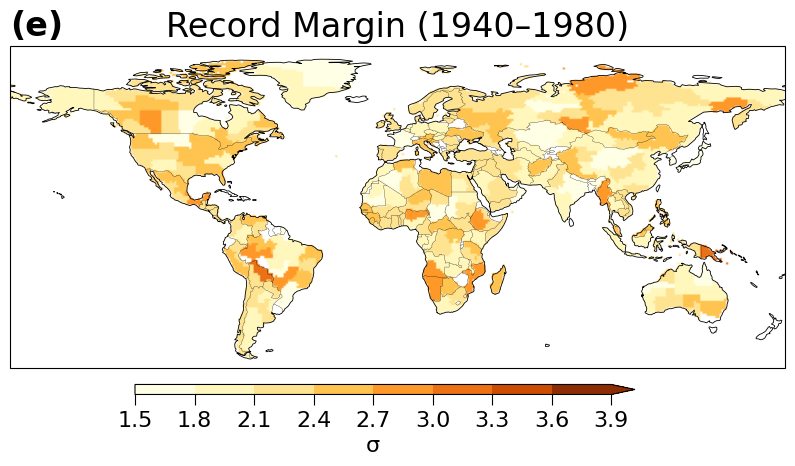

In [5]:
# ==========================================
# Figure (d): Record Anomaly (1940–1980)
# ==========================================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# ==========================================
# 1. Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "grid_comparison_fidelity_trend_corrected.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# ==========================================
# 2. Low fidelity mask
# ==========================================
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values
land_mask = ~np.isnan(region_id_map)
fill_grey_mask = land_mask & (~fidelity_mask)

SCATTER_STEP = 3
lon2d, lat2d = np.meshgrid(lon, lat)

sparse_mask = np.zeros_like(fill_grey_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = fill_grey_mask & sparse_mask

# ==========================================
# 3. Panel (d) calculation
# ==========================================
ds_sub = ds.sel(year=slice(1940, 1980))

mean_t2m = ds_sub["t2m_hottest"].mean(dim="year")
std_t2m = ds_sub["t2m_hottest"].std(dim="year")
max_record = ds_sub["t2m_hottest"].max(dim="year")

record_std_diff = (max_record - mean_t2m) / std_t2m

record_std_diff_map = np.full(region_id_map.shape, np.nan)

for rid in record_std_diff["region_id"].values:
    val = record_std_diff.sel(region_id=rid).item()
    record_std_diff_map[region_id_map.values == rid] = val

# ==========================================
# 4. Colormap
# ==========================================
bounds = [1.5, 1.8, 2.1, 2.4, 2.7, 3.0, 3.3, 3.6, 3.9]
# 0–1.5σ
colors_low = [
    "#ffffe5",
    "#fff7bc",
    "#fee391",
    "#fec44f"
]

# >1.5σ
colors_high = [
    "#fe9929",
    "#ec7014",
    "#cc4c02",
    "#8c2d04"
]

colors = colors_low + colors_high

cmap = ListedColormap(colors)
cmap.set_bad("white")
norm = BoundaryNorm(bounds, cmap.N)

# ==========================================
# 5. Remove zero values (set to NaN)
# ==========================================
record_std_diff_map_plot = record_std_diff_map.copy()
record_std_diff_map_plot[record_std_diff_map_plot == 0] = np.nan

# ==========================================
# 6. Plot function
# ==========================================
def plot_panel(data, title, label, filename):

    fig = plt.figure(figsize=(10,5))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    ax.set_extent([-180,180,-60,90])
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    ax.set_title(title, fontsize=24)

    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # ax.scatter(
    #     lon2d[low_fidelity_sparse],
    #     lat2d[low_fidelity_sparse],
    #     s=3,
    #     color="grey",
    #     marker="o",
    #     edgecolors="none",
    #     transform=ccrs.PlateCarree(),
    #     zorder=5
    # )

    ax.text(
        0.00,
        1.03,
        label,
        transform=ax.transAxes,
        fontsize=24,
        ha="left",
        fontweight='bold'
    )

    # colorbar
    cax = fig.add_axes([0.25,0.12,0.5,0.02])

    cb = fig.colorbar(
        plt.cm.ScalarMappable(cmap=cmap, norm=norm),
        cax=cax,
        orientation="horizontal",
        extend="max"
    )

    cb.set_label("σ", fontsize=16)
    cb.set_ticks([1.5, 1.8, 2.1, 2.4, 2.7, 3.0, 3.3, 3.6, 3.9])
    cb.ax.tick_params(labelsize=16, length=8)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# ==========================================
# 7. Generate figure (d)
# ==========================================
plot_panel(
    record_std_diff_map_plot,
    "Record Margin (1940–1980)",
    "(e)",
    "Fig_record_anomaly.pdf"
)

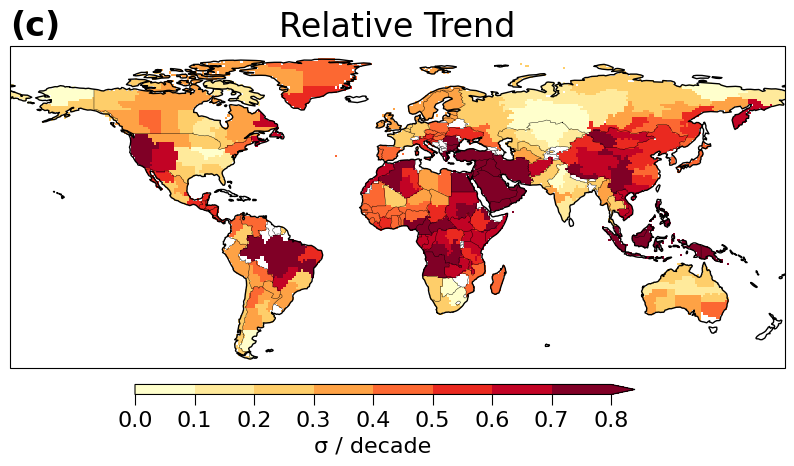

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import matplotlib.colors as mcolors

# =========================================================
# 1. Load datasets
# =========================================================
ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

region_ids = region_mask_ds['region_id'].values
lat = region_mask_ds['latitude'].values
lon = region_mask_ds['longitude'].values
n_regions = ds.region_id.size

lon2d, lat2d = np.meshgrid(lon, lat)

# =========================================================
# 2. Compute trends 1981-2024
# =========================================================
ds_sel_trend = ds.sel(year=slice(1981, 2024))
years_trend = ds_sel_trend.year.values

trend = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel_trend['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue
    slope, _, _, _, _ = linregress(years_trend, y)
    trend[i] = slope * 10.0  # K/decade

# =========================================================
# 3. Compute sigma 1940-1980
# =========================================================
ds_sel_sigma = ds.sel(year=slice(1940, 1980))
sigma = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel_sigma['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue
    sigma[i] = np.nanstd(y, ddof=1)

# =========================================================
# 4. Compute trend / sigma ratio
# =========================================================
trend_sigma_ratio = trend / sigma

# =========================================================
# 5. Map ratio to lat-lon grid
# =========================================================
ratio_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < n_regions:
        ratio_map[region_ids == rid] = trend_sigma_ratio[rid]

# =========================================================
# 6. Apply fidelity mask
# =========================================================
fidelity_mask = (fidelity_ds['fidelity_score'] == 3).values
GREY_VAL = -9999

masked_ratio = ratio_map.copy()

# 强制最小值为0（可根据需要调整）
MIN_LEVEL = 0
masked_ratio[(masked_ratio > GREY_VAL) & (masked_ratio < MIN_LEVEL)] = MIN_LEVEL

# Scatter mask for low fidelity
SCATTER_STEP = 3
low_fidelity_mask = (~fidelity_mask) & (~np.isnan(region_ids))
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask & sparse_mask

# =========================================================
# 7. Colormap
# =========================================================
levels = np.arange(0, 0.81, 0.1)  # ratio 的范围，可以调整
colors = plt.get_cmap("YlOrRd")(np.linspace(0, 1, len(levels) - 1))
cmap = mcolors.ListedColormap(['silver'] + list(colors))
bounds = [GREY_VAL - 0.5] + list(levels)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 8. Plot
# =========================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    lon,
    lat,
    masked_ratio,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Scatter low fidelity
# ax.scatter(
#     lon2d[low_fidelity_sparse],
#     lat2d[low_fidelity_sparse],
#     s=3,
#     color="grey",
#     marker="o",
#     edgecolors="none",
#     transform=ccrs.PlateCarree(),
#     zorder=5
# )

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
ax.set_title("Relative Trend", fontsize=24)

ax.text(
    0.0,
    1.03,
    '(c)',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
    ha="left"
)

# =========================================================
# 9. Colorbar
# =========================================================
cmap_cbar = mcolors.ListedColormap(colors)
norm_cbar = mcolors.BoundaryNorm(levels, cmap_cbar.N)

sm = plt.cm.ScalarMappable(cmap=cmap_cbar, norm=norm_cbar)
sm.set_array([])

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.02])
ticks = np.arange(0, 0.81, 0.1)

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=ticks,
    extend="max"
)
cbar.ax.tick_params(labelsize=16, length=8)
cbar.set_label("σ / decade", fontsize=16)

# =========================================================
# 10. Save
# =========================================================
plt.savefig(
    "ERA5_t2m_trend_over_sigma_1940_1980.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [8]:
import fitz  # PyMuPDF

# =====================================
# 1. 输入文件
# =====================================
files = [
    "time_series_region_a.pdf",
    "Fig_std_t2m_spatial.pdf",
    "ERA5_t2m_trend_hottest_month_1981_2024_masked.pdf",
    "Fig_record_anomaly.pdf",
    "Fig_record_margin.pdf",
    "Fig_record_period.pdf",
    "ERA5_t2m_trend_over_sigma_1940_1980.pdf"
]

img0, img1, img2, img3, img4, img5, img6 = files

# =====================================
# 2. 打开PDF
# =====================================
docs = [fitz.open(f) for f in files]

# 获取标准尺寸
w, h = docs[1][0].rect.width, docs[1][0].rect.height

# 顶部图尺寸
w0, h0 = docs[0][0].rect.width, docs[0][0].rect.height
top_width = w * 2
top_height = top_width * (h0 / w0)

# =====================================
# 3. 创建新PDF
# =====================================
canvas_width = w * 2
canvas_height = top_height + h * 3

new_doc = fitz.open()
page = new_doc.new_page(width=canvas_width, height=canvas_height)

# =====================================
# 4. 插入函数（核心：保持vector）
# =====================================
def insert_pdf(src_doc, x, y, width, height):
    src_page = src_doc[0]
    rect = fitz.Rect(x, y, x + width, y + height)
    page.show_pdf_page(rect, src_doc, 0)

# =====================================
# 5. 第一行
# =====================================
insert_pdf(docs[0], 0, 0, top_width, top_height)

# =====================================
# 6. 第二行
# =====================================
y = top_height
insert_pdf(docs[1], 0, y, w, h)
insert_pdf(docs[2], w, y, w, h)

# =====================================
# 7. 第三行
# =====================================
y = top_height + h
insert_pdf(docs[3], 0, y, w, h)
insert_pdf(docs[4], w, y, w, h)

# =====================================
# 8. 第四行
# =====================================
y = top_height + h * 2
insert_pdf(docs[5], 0, y, w, h)
insert_pdf(docs[6], w, y, w, h)

# =====================================
# 9. 保存
# =====================================
new_doc.save("FINAL_VECTOR_FIG.pdf")

print("✅ 完成：100%矢量拼接")

✅ 完成：100%矢量拼接


In [7]:
import fitz  # PyMuPDF

# =========================================================
# 1. 输入文件（6个PDF）
# =========================================================
files = [
    "ERA5_t2m_trend_hottest_month_1981_2024_masked.pdf",
    "Fig_std_t2m_spatial.pdf",
    "ERA5_t2m_trend_over_sigma_1940_1980.pdf",
    "Fig_record_period.pdf",
    "Fig_record_anomaly.pdf",
    "Fig_record_margin.pdf",
]

# =========================================================
# 2. 打开PDF
# =========================================================
docs = [fitz.open(f) for f in files]

# =========================================================
# 3. 获取统一尺寸（以第一个图为基准）
# =========================================================
base_page = docs[0][0]

w = base_page.rect.width
h = base_page.rect.height

# =========================================================
# 4. 布局参数
# =========================================================
ncols = 3
nrows = 2

# 页边距（可自行调整）
margin_x = 20
margin_y = 20

# 子图之间间距
gap_x = 10
gap_y = 10

# =========================================================
# 5. 创建输出PDF
# =========================================================
canvas_width = ncols * w + (ncols - 1) * gap_x + 2 * margin_x
canvas_height = nrows * h + (nrows - 1) * gap_y + 2 * margin_y

new_doc = fitz.open()

page = new_doc.new_page(
    width=canvas_width,
    height=canvas_height
)

# =========================================================
# 6. 插入函数（保持100%矢量）
# =========================================================
def insert_pdf(src_doc, x, y, width, height):
    rect = fitz.Rect(x, y, x + width, y + height)
    page.show_pdf_page(rect, src_doc, 0)

# =========================================================
# 7. 按“三行两列”排列
# =========================================================
for i, doc in enumerate(docs):

    row = i // ncols
    col = i % ncols

    x = margin_x + col * (w + gap_x)
    y = margin_y + row * (h + gap_y)

    insert_pdf(doc, x, y, w, h)

# =========================================================
# 8. 保存
# =========================================================
output_file = "FINAL_VECTOR_FIG_3x2.pdf"

new_doc.save(output_file)

# 关闭文件
for d in docs:
    d.close()

new_doc.close()

print(f"✅ 完成：100%矢量拼接")
print(f"输出文件: {output_file}")

✅ 完成：100%矢量拼接
输出文件: FINAL_VECTOR_FIG_3x2.pdf
